## This file contains code for our coefficient plot analysis 

In [14]:
import pandas as pd 
import numpy as np 
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
# load demographic ABC data 
demographic_abcs = pd.read_csv('../data/demographic_abcs.csv')
demographic_abcs.head()

,Local ID,Date Reviewed,Type of Service,Irritability/Agitation,Lethargy/Social Withdrawal,Stereotypic Behavior,Hyperactivity/Noncompliance,Inappropriate Speech,Date Enrolled in START,Status,...,Current IEP,Current 504 Plan,School Setting,Custody Status,Child Lives With,norm_leth_soc,norm_ir_agit,norm_stereo,norm_hyper,norm_speech
0,11153125,10/26/2016,Re-evaluation,3.0,2.0,0.0,0.0,0.0,4/1/2013,Active,...,No,No,NaN,NaN,NaN,4.166667,6.666667,0.000000,0.000000,0.000000
1,11153125,4/11/2017,Re-evaluation,3.0,2.0,NaN,NaN,NaN,4/1/2013,Active,...,No,No,NaN,NaN,NaN,4.166667,6.666667,NaN,NaN,NaN
2,11153125,10/11/2017,Re-evaluation,2.0,1.0,0.0,0.0,NaN,4/1/2013,Active,...,No,No,NaN,NaN,NaN,2.083333,4.444444,0.000000,0.000000,NaN
3,11153125,6/21/2018,Re-evaluation,19.0,19.0,4.0,8.0,0.0,4/1/2013,Active,...,No,No,NaN,NaN,NaN,39.583333,42.222222,19.047619,16.666667,0.000000
4,11153125,9/24/2018,Re-evaluation,10.0,11.0,3.0,6.0,2.0,4/1/2013,Active,...,No,No,NaN,NaN,NaN,22.916667,22.222222,14.285714,12.500000,16.666667


In [16]:
# taking the mean of ABC score categories 

mean_cols = demographic_abcs[["norm_leth_soc", "norm_ir_agit", "norm_stereo", "norm_hyper", "norm_speech"]]
demographic_abcs.dropna(subset=["norm_leth_soc", "norm_ir_agit", "norm_stereo", "norm_hyper", "norm_speech"], inplace=True)
demographic_abcs["mean_abc"] = mean_cols.mean(axis=1)

pivot_table = demographic_abcs.pivot_table(index='Local ID', columns='Type of Service', values='mean_abc')

pivot_table.dropna(subset=['Intake', 'Re-evaluation'], inplace=True)
pivot_table['diff_mean_abc'] = pivot_table['Re-evaluation'] - pivot_table['Intake']
demographic_abcs = demographic_abcs.merge(pivot_table[['diff_mean_abc']], left_on='Local ID', right_index=True)


In [17]:
# Creating the Design Matrix 

# creating dummy variables on the demographic categories 

design_matrix = pd.get_dummies(demographic_abcs, columns=["Race", "Gender", "Level of Intellectual Disability",
                                                "More than one living situation over the last 5 years?",
                                                "History of Child Protective Services involvement in past year (at enrollment to START)",
                                                "Psychiatric hospitalization in past year (at enrollment to START)"])
y = design_matrix['diff_mean_abc']
X = design_matrix[design_matrix.columns[53:]].astype(int)
X = sm.add_constant(X)
result = sm.OLS(y, X).fit()
print(result.summary())


                            OLS Regression Results                            
Dep. Variable:          diff_mean_abc   R-squared:                       0.013
Model:                            OLS   Adj. R-squared:                  0.010
Method:                 Least Squares   F-statistic:                     5.656
Date:                Sat, 01 Jun 2024   Prob (F-statistic):           5.40e-27
Time:                        19:35:42   Log-Likelihood:                -72251.
No. Observations:               17432   AIC:                         1.446e+05
Df Residuals:                   17392   BIC:                         1.449e+05
Df Model:                          39                                         
Covariance Type:            nonrobust                                         
                                                                                                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------

In [18]:
# creating a summary table and looking at the coeficient 

AA = result.summary().tables[1].data
AA = pd.DataFrame(AA)
AA.columns = AA.iloc[0]
AA = AA.iloc[1:]
AA[AA.columns[1:]] = AA[AA.columns[1:]].astype(float)
AA.columns = ["vari", "coef", "std_err", "t", "p_val", "low_b", "up_b"]

BB = AA.sort_values("coef", ascending=True)
BB = BB.reset_index(drop=True)

/var/folders/cw/mcjy6_9d6y5grbrjcwh5x8280000gn/T/ipykernel_40083/655453785.py:27: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  for lh in legend.legendHandles:


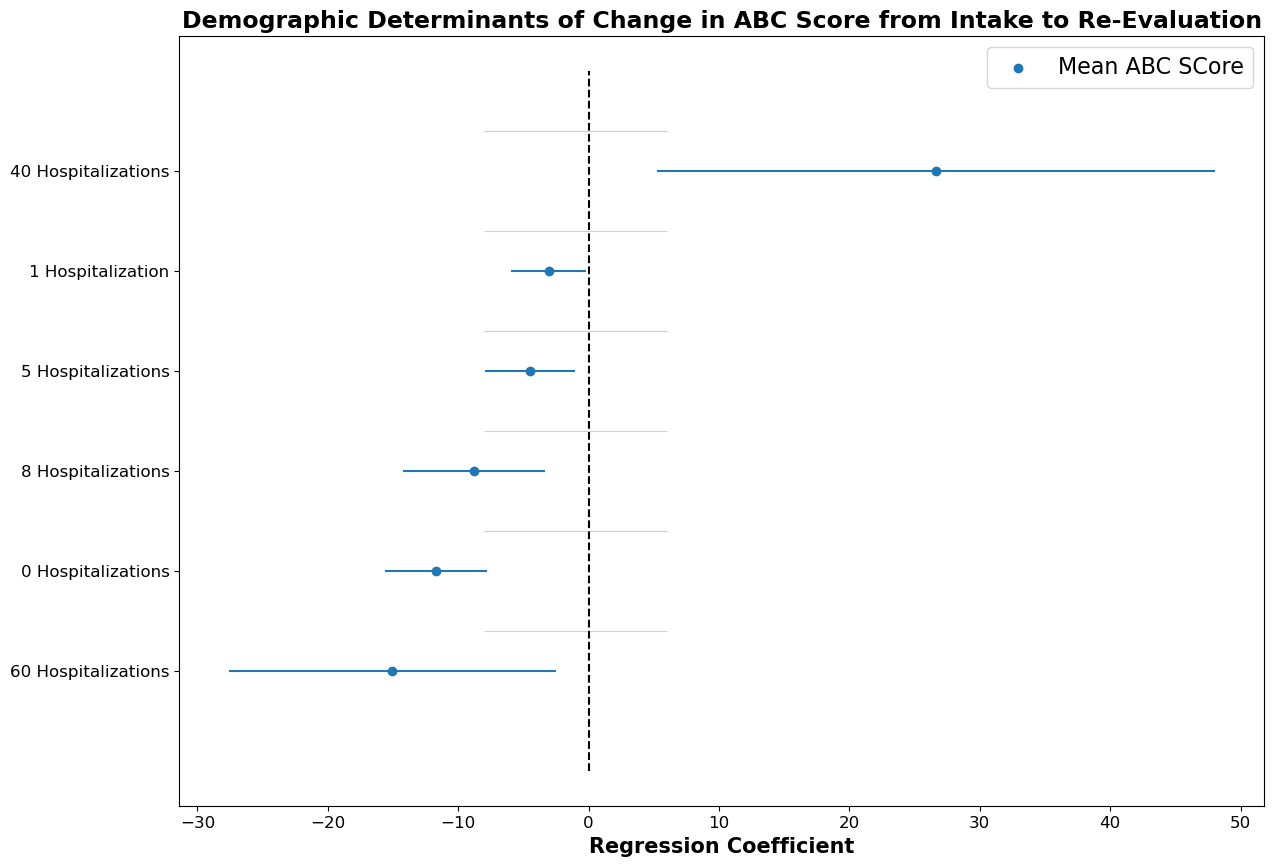

In [22]:

plt.figure(figsize=(14,10))
#cols = [ "darkturquoise",  "navy", "forestgreen", "firebrick"]
w = 0.1

result = sm.OLS(y, X).fit()

# print(result.summary())

# filtering the data to statistical significance is p <0.05
AA = result.summary().tables[1].data
AA = pd.DataFrame(AA)
AA.columns = AA.iloc[0]
AA = AA.iloc[1:]
AA[AA.columns[1:]] = AA[AA.columns[1:]].astype(float)
AA.columns = ["vari", "coef", "std_err", "t", "p_val", "low_b", "up_b" ]
BB = AA[AA.p_val < 0.05]
BB = BB.sort_values("coef", ascending = True)
BB = BB.reset_index(drop=True)

# aesthetic features of the plot 
plt.hlines(BB.index, BB.low_b, BB.up_b)
plt.scatter(BB.coef,BB.index, label = "Mean ABC SCore")
plt.legend(fontsize='small')
plt.vlines(0,0-1,len(BB), linestyle = "--", color = "black")
plt.yticks(BB.index,BB.vari, fontsize=12)


legend = plt.legend(fontsize=16)
for lh in legend.legendHandles:
     lh.set_alpha(1)
# plt.ylim(len(BB))
# plt.xlim(-30,20)

for i in range(len(BB)):
     plt.hlines(i+0.40, -8, 6, alpha=0.3, linewidth=0.8 )

# cleaning up the figure...focusing on axes 
yticks = ["40 Hospitalizations", "1 Hospitalization", "5 Hospitalizations", "8 Hospitalizations", "0 Hospitalizations", "60 Hospitalizations"]
plt.yticks(BB.index, yticks[::-1], fontsize=12)

plt.xticks(fontsize = 12)
plt.xlabel("Regression Coefficient", fontsize=15, fontweight = "bold")
plt.title("Demographic Determinants of Change in ABC Score from Intake to Re-Evaluation", fontsize = 17, fontweight = "bold")
plt.savefig("../output/coefficient_plot.png")
plt.show()

/var/folders/cw/mcjy6_9d6y5grbrjcwh5x8280000gn/T/ipykernel_40083/563208901.py:9: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  for lh in legend.legendHandles:


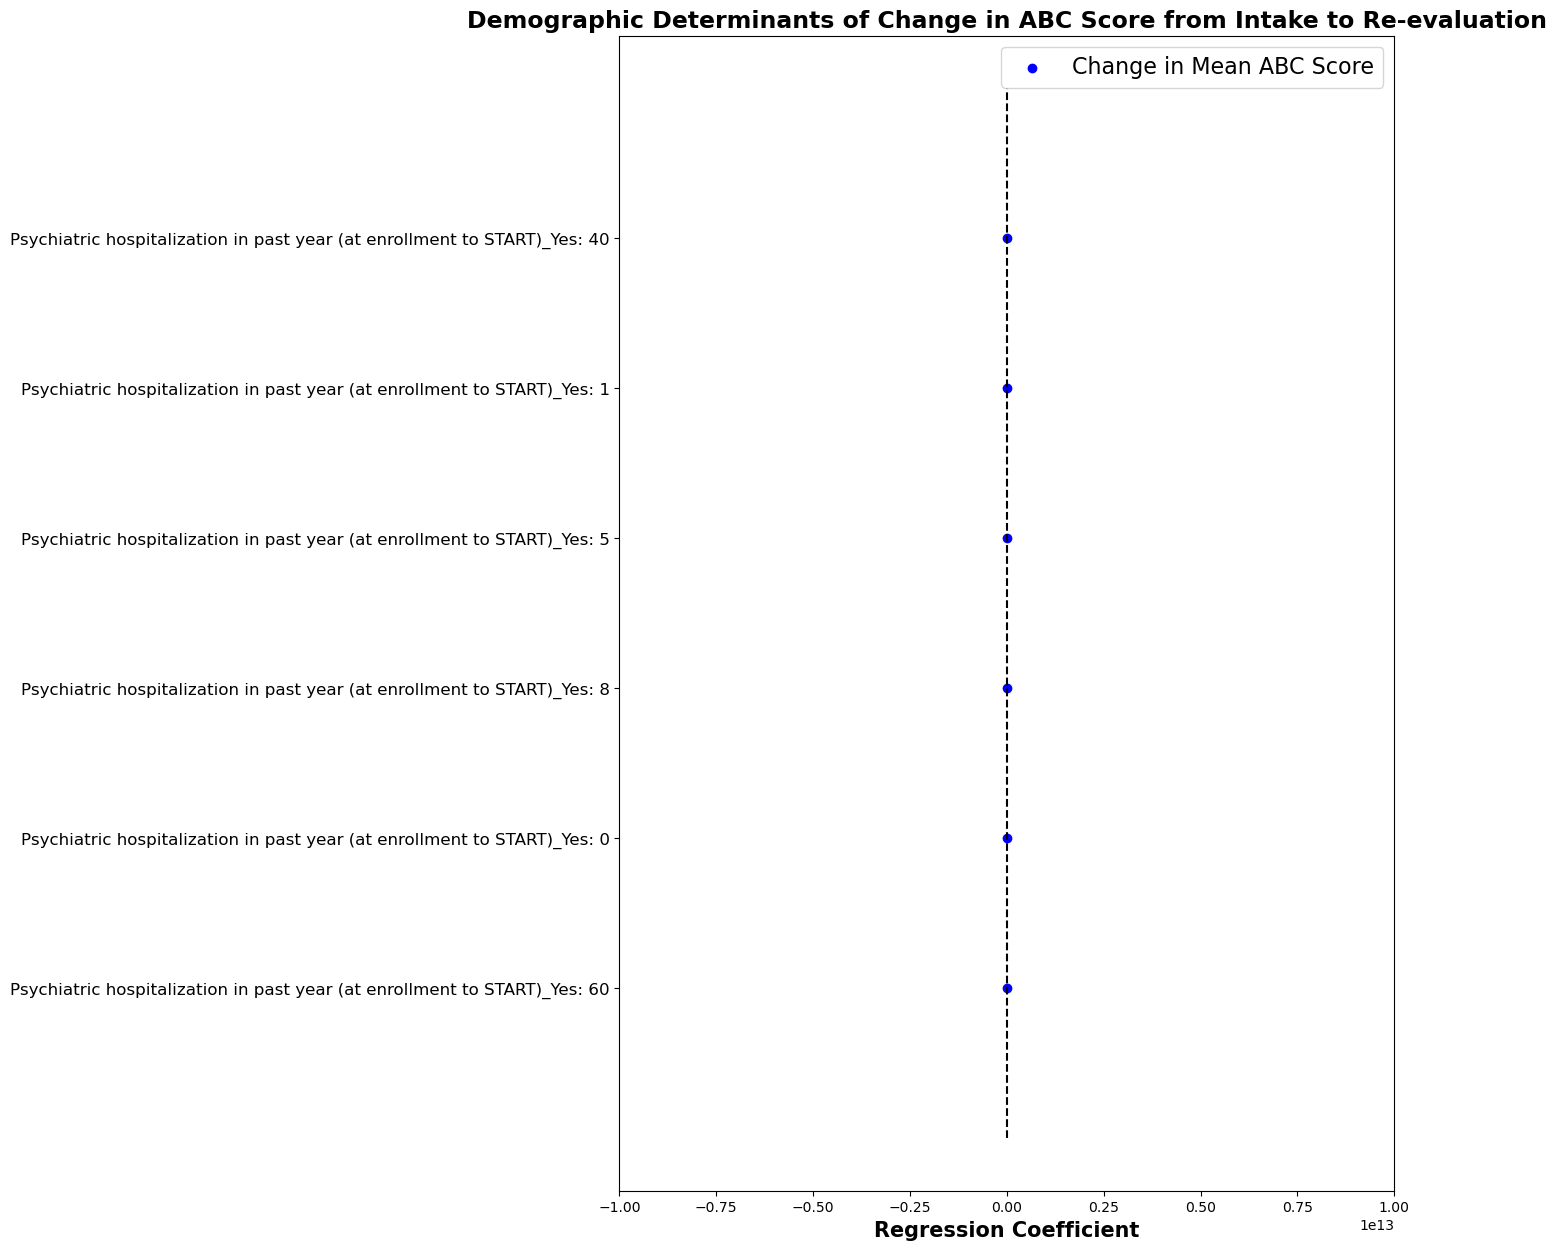

In [13]:
# Old Code to Be Commented Out (Variation of Above)


#plt.figure(figsize=(10, 15))
#plt.hlines(BB.index, BB.low_b, BB.up_b, color='skyblue')
#plt.scatter(BB.coef, BB.index, label="Change in Mean ABC Score", color='blue')
#plt.legend(fontsize='small')
#plt.vlines(0, -1, len(BB), linestyle="--", color="black")
#plt.yticks(BB.index, BB.vari, fontsize=12)

#legend = plt.legend(fontsize=16)
#for lh in legend.legendHandles:
#    lh.set_alpha(1)
#plt.xlim(-1e13, 1e13)  # Set x-axis limit to -1 to 1

#for i in range(len(BB)):
#    plt.hlines(i + 0.40, BB.low_b[i], BB.up_b[i], alpha=0.3, linewidth=0.8)

#plt.xticks(fontsize=10)
#plt.xlabel("Regression Coefficient", fontsize=15, fontweight="bold")
#plt.title("Demographic Determinants of Change in ABC Score from Intake to Re-evaluation", fontsize=17, fontweight="bold")
#plt.show()

In [8]:
# Old Code To Be Commented Out: Create coefficient plot 

# # Fit linear regression model
# model = sm.OLS(y, X).fit()

# # Get coefficients summary
# coefs_sumz = model.params
# coefs_std_err = model.bse

# # Extract coefficients and standard errors
# coefz_df = pd.DataFrame({
#     'outcome': X.columns,
#     'coefs': coefs_sumz.values,
#     'ses': coefs_std_err.values
# })

# # Plot coefficients
# plt.figure(figsize=(10, 14))
# sns.set_style("whitegrid")
# sns.barplot(x = 'outcome', y = 'coefs', data = coefz_df, ci = None, color = 'skyblue')
# plt.errorbar(x = coefz_df['outcome'], y = coefz_df['coefs'], yerr = 1.96*coefz_df['ses'], fmt = 'none', c = 'red', capsize = 5)
# plt.axhline(y = 0, color = 'red', linestyle='--', linewidth = 0.6)
# plt.xlabel('Outcome')
# plt.ylabel('Effect')
# plt.title('Impact of Observable Characteristics on Mean ABC Score')
# plt.xticks(rotation = 45, ha = 'right')
# plt.tight_layout()
# plt.show()